<a href="https://colab.research.google.com/github/apurvak3/Machine_Learning/blob/main/Hierarchial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.decomposition import PCA

In [3]:
df = pd.read_csv('/content/mall.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
X = df.iloc[:,[3,4]]
X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


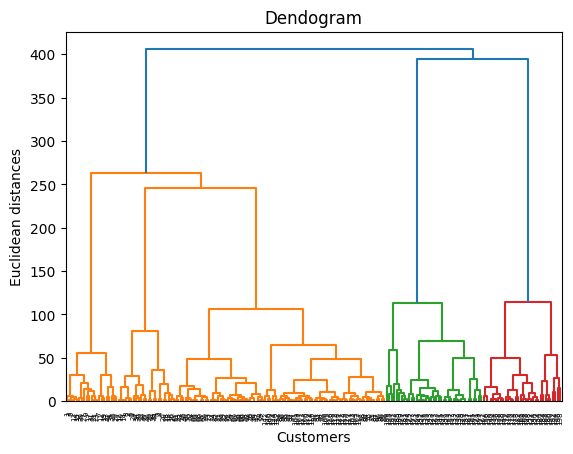

In [6]:
dendogram = sch.dendrogram(sch.linkage(X, method='ward'))
plt.title('Dendogram')
plt.xlabel('Customers')
plt.ylabel('Euclidean distances')
plt.show()

In [8]:
ac = AgglomerativeClustering(n_clusters=4, metric='euclidean', linkage='ward')
y_hc = ac.fit_predict(X)

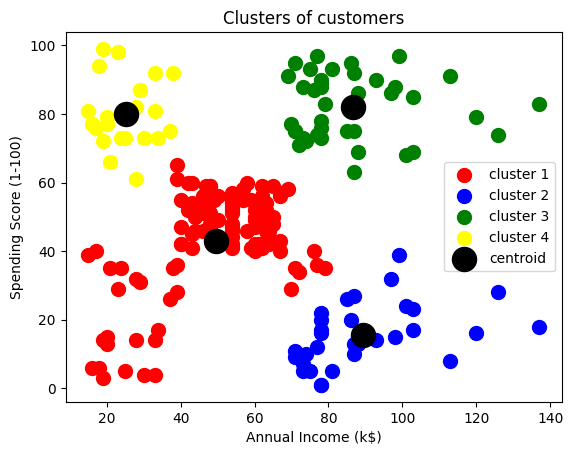

In [10]:
##visualize the cluster

# Convert X to numpy array for easier indexing
X_np = X.values

# Calculate cluster centers manually as AgglomerativeClustering does not directly provide cluster_centers_
centroids = []
for i in range(ac.n_clusters):
    centroids.append(X_np[y_hc == i].mean(axis=0))
centroids = np.array(centroids)

plt.scatter(X_np[y_hc == 0,0],X_np[y_hc == 0,1],s=100,c='red',label='cluster 1')
plt.scatter(X_np[y_hc == 1,0],X_np[y_hc == 1,1],s=100,c='blue',label='cluster 2')
plt.scatter(X_np[y_hc == 2,0],X_np[y_hc == 2,1],s=100,c='green',label='cluster 3')
plt.scatter(X_np[y_hc == 3,0],X_np[y_hc == 3,1],s=100,c='yellow',label='cluster 4')
plt.scatter(centroids[:,0],centroids[:,1],s=300,c='black',label='centroid')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Clusters of customers')
plt.legend()
plt.show()